In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)

# Define Lotka Volterra Simulator
def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

def simulate_total(parameters, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]

    y0 = np.asarray([40.0, 9.0])  # Initial populations
    #t_span = 400  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(2*t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

def choose_splitter(nparray, split_method):
    if split_method == 'even_odd':
        return split_by_even_odd(nparray)
    elif split_method == 'first_second':
        return split_in_two(nparray)
    else:
        raise ValueError(f"Unknown split type: {split_method}")
    

# split into two halves
def split_in_two(nparray):
    n = len(nparray)
    mid = n//2
    res1 = nparray[:mid]
    res2 = nparray[mid:]
    return res1, res2

# split by even/odd indices
def split_by_even_odd(nparray):
    even = nparray[::2]
    odd = nparray[1::2]
    m = min(len(even), len(odd))
    even, odd = even[:m], odd[:m]
    return even, odd


# Define how populations evolve
def simulate(parameters, observation, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]


    y0 = np.asarray([observation[0, 0], observation[0, 1]])  # Initial populations
    #t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx

# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")

# Use mean and max as summary statistics but add noise: intended for our actual observation
def add_noise_and_plot(simulation_result, distn, sigma_hare, sigma_lynx, time):

    if distn == 'none':
        pass
    elif distn == 'gaussian':
        noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=simulation_result.shape)
        simulation_result = simulation_result + noise
    elif distn == 'poisson':
        lam = np.clip(simulation_result, 1e-6, None)
        simulation_result = np.random.poisson(lam)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")

    plot_observed_data(time,simulation_result)

    
    return simulation_result

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation, t_span):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation,t_span)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    latent = simulate_match_data(parameters, n_obs,observation, t_span)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation, t_span):
    latent = simulate_match_data(parameters, n_obs, observation, t_span)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation,t_span)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation, t_span)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# Define a uniform prior
def define_uniform_prior():
    lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
    upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
    prior = BoxUniform(low=lower_bound, high=upper_bound)
    return prior

# Define a log-normal prior
def define_logn_prior():
    log_means = torch.log(torch.tensor([
        0.13,   # alpha - 1.6 old: 0.1
        0.015,   # beta - 3.2 old: 0.02
        0.008,  # delta - 0.6
        0.12    # gamma - 0.56
    ]))

    log_stds = torch.tensor([0.3, 0.3, 0.3, 0.3])

    # Build prior
    base_dist = LogNormal(loc=log_means, scale=log_stds)
    prior_lognormal = Independent(base_dist, 1)
    return prior_lognormal


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(distn):
    if distn == 'uniform':
        prior = define_uniform_prior()
    elif distn == 'logn':
        prior = define_logn_prior()
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    
    theta = prior.sample((10_000,))
    return prior, theta

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 24
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation, t_span)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation, t_span):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation, t_span)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=[[0, 200], [0, 150], [0, 25], [0, 50]],
        figsize=(4, 4),
    )


In [2]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior_direct = inference.build_posterior(density_estimator=posterior_net,sample_with="direct")
    posterior_mcmc = inference.build_posterior(density_estimator=posterior_net,sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples,
            points = true_val[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
        
    return samples, posterior_mcmc, posterior_direct, inference

In [5]:
'''

results = {
        "samples1": samples1,          # posterior samples (1000, 4)
        "samples2": samples2,          # posterior samples (1000, 4)
        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)
        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)
        "inference1": inference1,      # NPE object
        "inference2": inference2,      # NPE object
        "prior1": prior1,
        "prior2": prior2,
        "theta1": theta1,              # simulated θ used for training (10000, 4)
        "theta2": theta2,              # simulated θ used for training (10000, 4)
        "x1": x1,                      # simulated summaries (10000, 4)
        "x2": x2,                      # simulated summaries (10000, 4)
        "x_obs1": x_obs1,              # observed summary (4,)
        "x_obs2": x_obs2,              # observed summary (4,)
        "time_vec1": time1,        # years
        "time_vec2": time2,        # years
        "obs1": obs1,  # raw data (n_obs, 2)
        "obs2": obs2,  # raw data (n_obs, 2)
        "prior_name": prior_name,    # 'uniform' or 'logn'
        "noise1": noise1,        # 'none' / 'gaussian' / 'poisson'
        "noise2": noise2,        # 'none' / 'gaussian' / 'poisson'
        "n_obs1": n_obs1,
        "n_obs2": n_obs2,
        "sigma_hare1": sigma_hare1,
        "sigma_lynx1": sigma_lynx1,
        "sigma_hare2": sigma_hare2,
        "sigma_lynx2": sigma_lynx2,
        "split_type": split_type,
        "t_span": t_span
    }

fname = f"CALIBRATION TESTER_split_{split_type}_results_{prior_name}_{noise1}.pt"
torch.save(results, fname)

'''

'\n\nresults = {\n        "samples1": samples1,          # posterior samples (1000, 4)\n        "samples2": samples2,          # posterior samples (1000, 4)\n        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)\n        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)\n        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)\n        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)\n        "inference1": inference1,      # NPE object\n        "inference2": inference2,      # NPE object\n        "prior1": prior1,\n        "prior2": prior2,\n        "theta1": theta1,              # simulated θ used for training (10000, 4)\n        "theta2": theta2,              # simulated θ used for training (10000, 4)\n        "x1": x1,                      # simulated summaries (10000, 4)\n        "x2": x2,                      # simulated 

In [3]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior1", "prior2",
        "theta1", "theta2",
        "x1", "x2",
        "x_obs1", "x_obs2",
        "time_vec1", "time_vec2",
        "obs1", "obs2",
        "prior_name",
        "noise1", "noise2",
        "n_obs1", "n_obs2",
        "sigma_hare1", "sigma_lynx1",
        "sigma_hare2", "sigma_lynx2",
        "split_type", "t_span", "true_parameters"
    ]

    # update to include t_span when we retrain models

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [4]:
fname1 = "CALIBRATION TESTER_split_even_odd_results_uniform_poisson.pt"
fname2 = "CALIBRATION TESTER_split_first_second_results_uniform_poisson.pt"
fname3 = "CALIBRATION TESTER_split_even_odd_results_logn_poisson.pt"
fname4 = "CALIBRATION TESTER_split_first_second_results_logn_poisson.pt"

fname5 = "CALIBRATION TESTER_split_even_odd_results_logn_poisson_1000EPOCH.pt"
fname6 = "CALIBRATION TESTER_split_first_second_results_logn_poisson_1000EPOCH.pt"

# === CHANGE (2026-05-06): new same-noise training files. Saved by the
# updated LV_KL_Calibrate notebook with `noise = 'gaussian'` (or whatever
# shared training noise was used). Both splits are trained on identical
# null-noise simulations; the systematic is injected only at test time.
# ===
fname_eo_gauss = "CALIBRATION TESTER_split_even_odd_results_logn_gaussian_SAMENOISE_1000EPOCH.pt"
fname_fs_gauss = "CALIBRATION TESTER_split_first_second_results_logn_gaussian_SAMENOISE_1000EPOCH.pt"

# Pick whichever file you want to test; default to the new same-noise gaussian run.
res = load_results_file(fname_eo_gauss)  # change to fname_eo_gauss / fname_fs_gauss after retraining
# update to include t_span when we retrain models
# update to include true_params if needed but think first
(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior1, prior2,
 theta1, theta2,
 x1, x2,
 x_obs1, x_obs2,
 time1, time2,
 obs1, obs2,
 prior_name,
 noise1, noise2,
 n_obs1, n_obs2,
 sigma_hare1, sigma_lynx1,
 sigma_hare2, sigma_lynx2,
 split_type, t_span, true_parameters) = extract_results(res)

# === CHANGE (2026-05-06): expose a single `noise_train` alias.
# Under the new methodology, noise1 == noise2 == training noise. We use
# `noise_train` everywhere downstream so it is unambiguous.
# Backwards-compat: if results dict has the new "noise" key, use it; else
# fall back to noise1 (which equalled noise2 in any sane saved file).
noise_train = res.get("noise", noise1)
assert noise1 == noise2, (
    "Loaded result has different noise on each split — that is the OLD "
    "(incorrect) regime. Retrain with the updated LV_KL_Calibrate."
)


/tmp/ipykernel_848166/1040296050.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


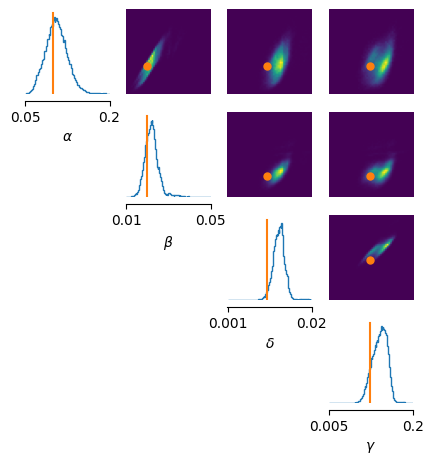

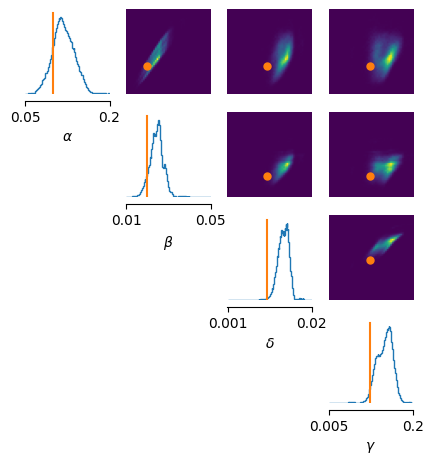

In [5]:

_ = pairplot(
            samples1,
            points = true_parameters[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
_ = pairplot(
            samples2,
            points = true_parameters[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )

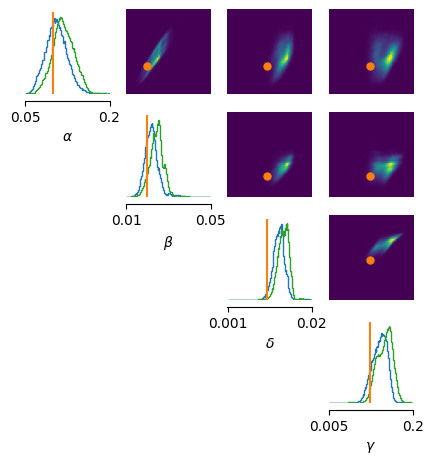

In [6]:
# overlay posteriors

_ = pairplot(
    [samples1, samples2],                       
    points=true_parameters[None, :],
    limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
    ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
    figsize=(5, 5),
    labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
)

#### Better pairplots (Will's Apr-9 / Apr-14 asks)

Prior shrinkage and split-1 vs split-2 overlays in both `sbi.pairplot` and `getdist` flavours. (No Fisher panel — the LV ODE has no closed-form score.)


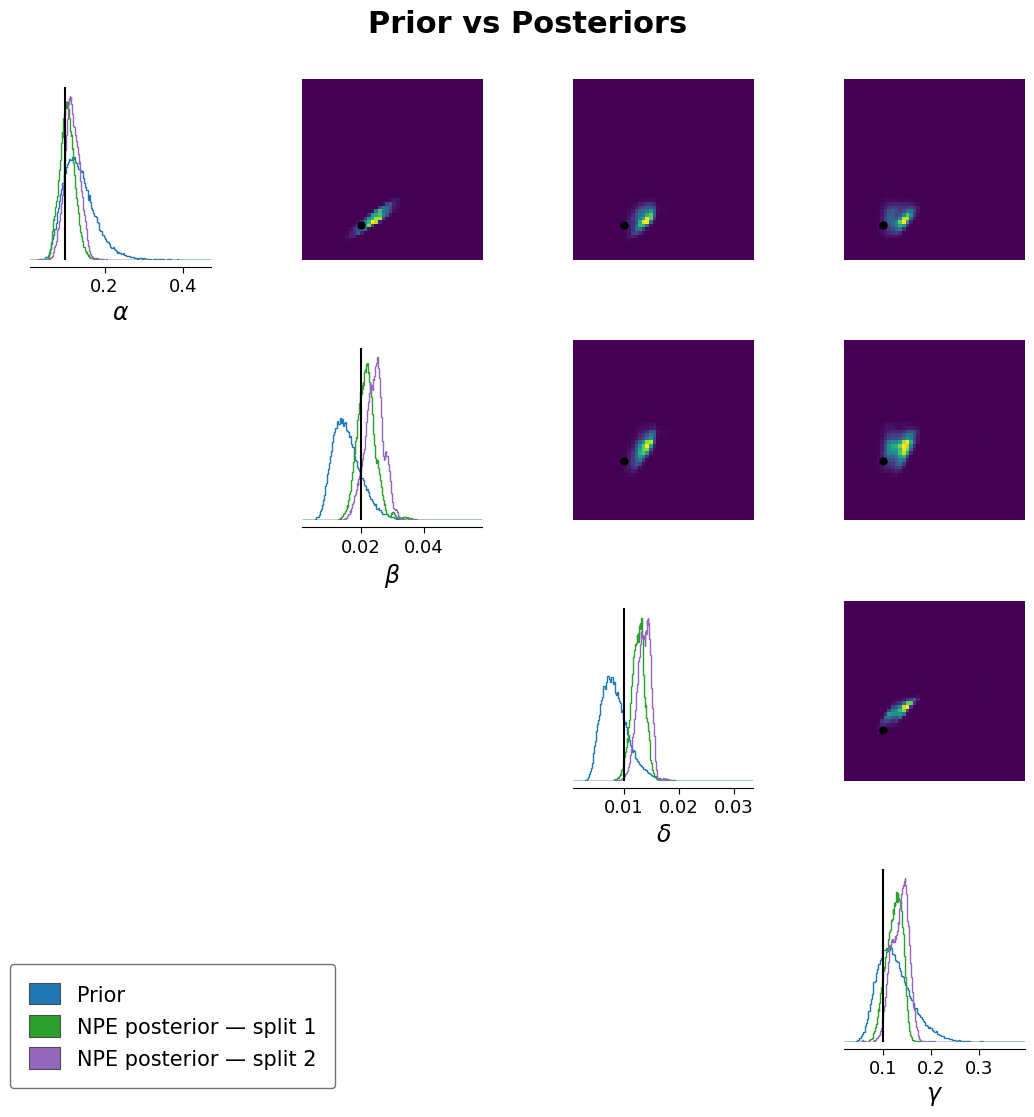

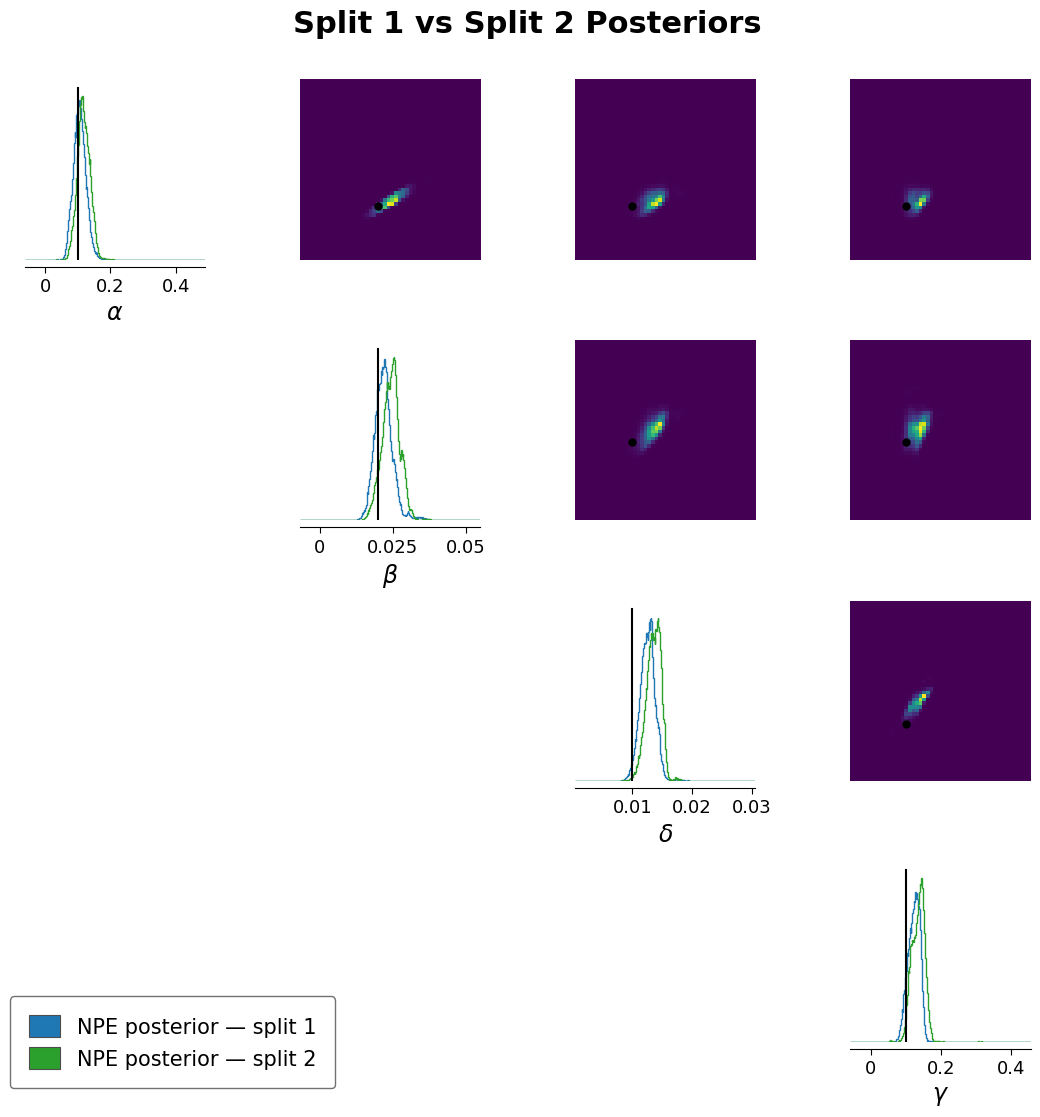

In [7]:
# ============================================================
# Presentation-quality pairplots — sbi.pairplot version
# (Lotka-Volterra has no closed-form Fisher information; we just
#  show prior shrinkage and the null vs perturbed posteriors.)
# ============================================================

import matplotlib as mpl
import matplotlib.patches as mpatches

_RC = {
    "font.size":       16,
    "axes.labelsize":  18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.titlesize":  16,
}

LV_PARAM_LABELS = [r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]


def _style_axes(axes):
    for row in axes:
        for ax in row:
            if ax is None:
                continue
            ax.tick_params(axis="both", labelsize=13, length=4, width=0.8)
            ax.xaxis.label.set_size(17)
            ax.yaxis.label.set_size(17)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)


def _add_legend(fig, entries):
    handles = [mpatches.Patch(facecolor=c, edgecolor="0.3", linewidth=0.8, label=lbl)
               for c, lbl in entries]
    leg = fig.legend(
        handles=handles, fontsize=15, frameon=True,
        facecolor="white", edgecolor="0.3",
        loc="lower left", bbox_to_anchor=(0.02, 0.02),
        borderpad=0.9, handlelength=1.5, handleheight=1.2,
    )
    leg.get_frame().set_linewidth(1.0)


def _to_tensor(s):
    if not torch.is_tensor(s):
        s = torch.tensor(np.asarray(s, dtype=np.float32))
    return s.clone().float()


def _empirical_limits(samples_list, pad_frac=0.05):
    arr = np.concatenate([s.numpy() if torch.is_tensor(s) else np.asarray(s, dtype=float)
                          for s in samples_list], axis=0)
    mn, mx = arr.min(axis=0), arr.max(axis=0)
    pad    = pad_frac * (mx - mn)
    return [[mn[i] - pad[i], mx[i] + pad[i]] for i in range(arr.shape[1])]


def plot_prior_vs_posteriors_lv(samples1, samples2, prior, true_parameters,
                                 systematic_label=None, n_prior_samples=50_000):
    """Prior vs both NPE posteriors. Limits set from prior support."""
    prior_samples = prior.sample((n_prior_samples,))
    prior_plot    = _to_tensor(prior_samples)
    post1_plot    = _to_tensor(samples1)
    post2_plot    = _to_tensor(samples2)

    true_plot = _to_tensor(np.asarray(true_parameters, dtype=float).reshape(1, -1)).squeeze(0)

    sys_label = systematic_label or "NPE posterior — split 2"

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[prior_plot, post1_plot, post2_plot],
            points=true_plot[None, :],
            limits=_empirical_limits([prior_plot]),
            figsize=(11, 11),
            labels=LV_PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "Prior"),
        ("#2ca02c", "NPE posterior — split 1"),
        ("#9467bd", sys_label),
    ])
    fig.suptitle("Prior vs Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_posteriors_overlaid_lv(samples1, samples2, true_parameters,
                                  systematic_label=None):
    """Just the two posteriors, tight limits."""
    post1_plot = _to_tensor(samples1)
    post2_plot = _to_tensor(samples2)

    true_plot = _to_tensor(np.asarray(true_parameters, dtype=float).reshape(1, -1)).squeeze(0)

    sys_label = systematic_label or "NPE posterior — split 2"

    tight_limits = _empirical_limits([post1_plot, post2_plot], pad_frac=0.15)

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot],
            points=true_plot[None, :],
            limits=tight_limits,
            figsize=(11, 11),
            labels=LV_PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — split 1"),
        ("#2ca02c", sys_label),
    ])
    fig.suptitle("Split 1 vs Split 2 Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_prior_vs_posteriors_lv(
    samples1, samples2, prior1, true_parameters,
    systematic_label="NPE posterior — split 2",
)

plot_posteriors_overlaid_lv(
    samples1, samples2, true_parameters,
    systematic_label="NPE posterior — split 2",
)


Removed no burn in
Removed no burn in
Removed no burn in


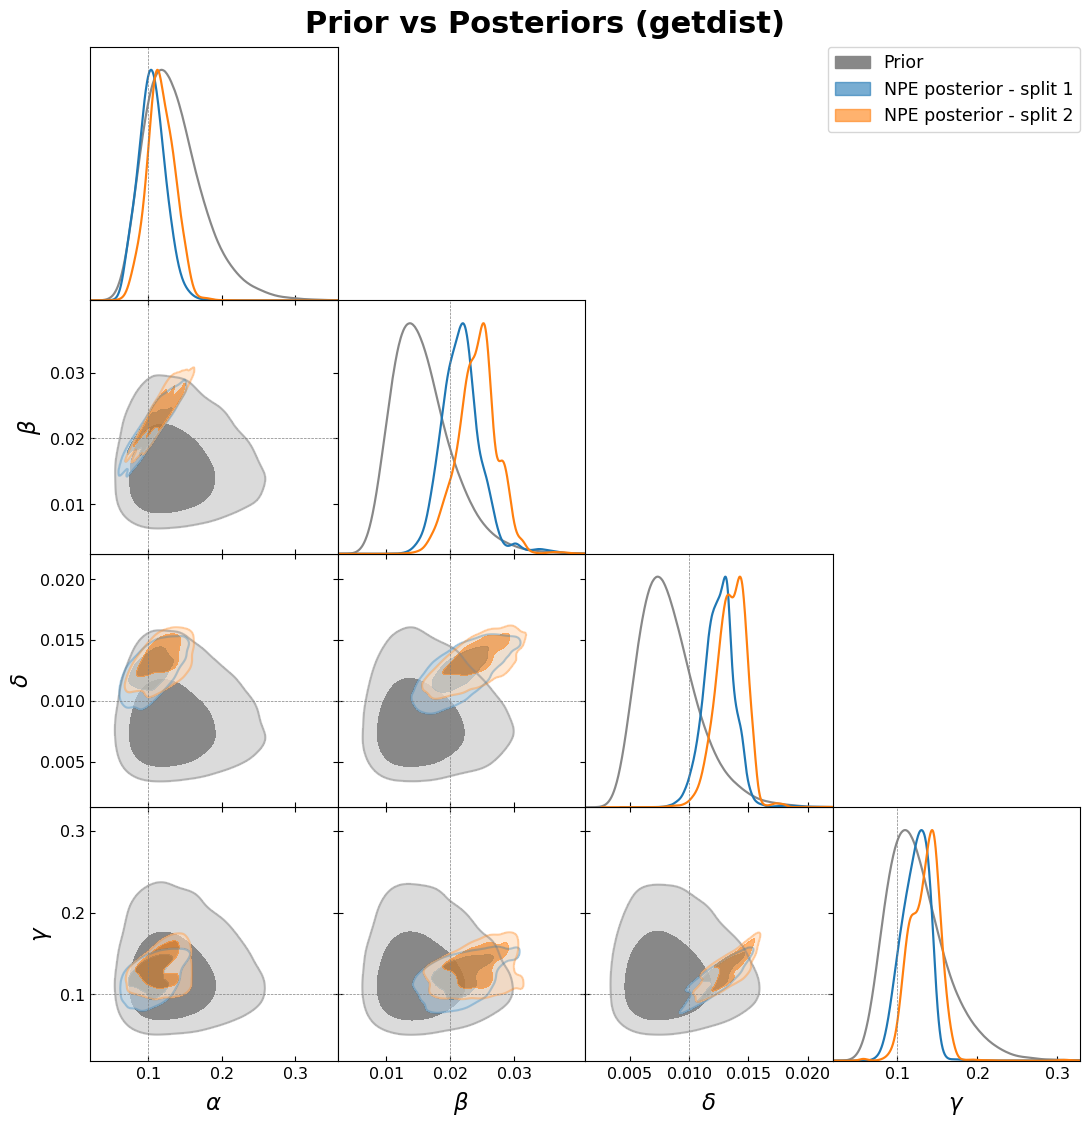

Removed no burn in
Removed no burn in


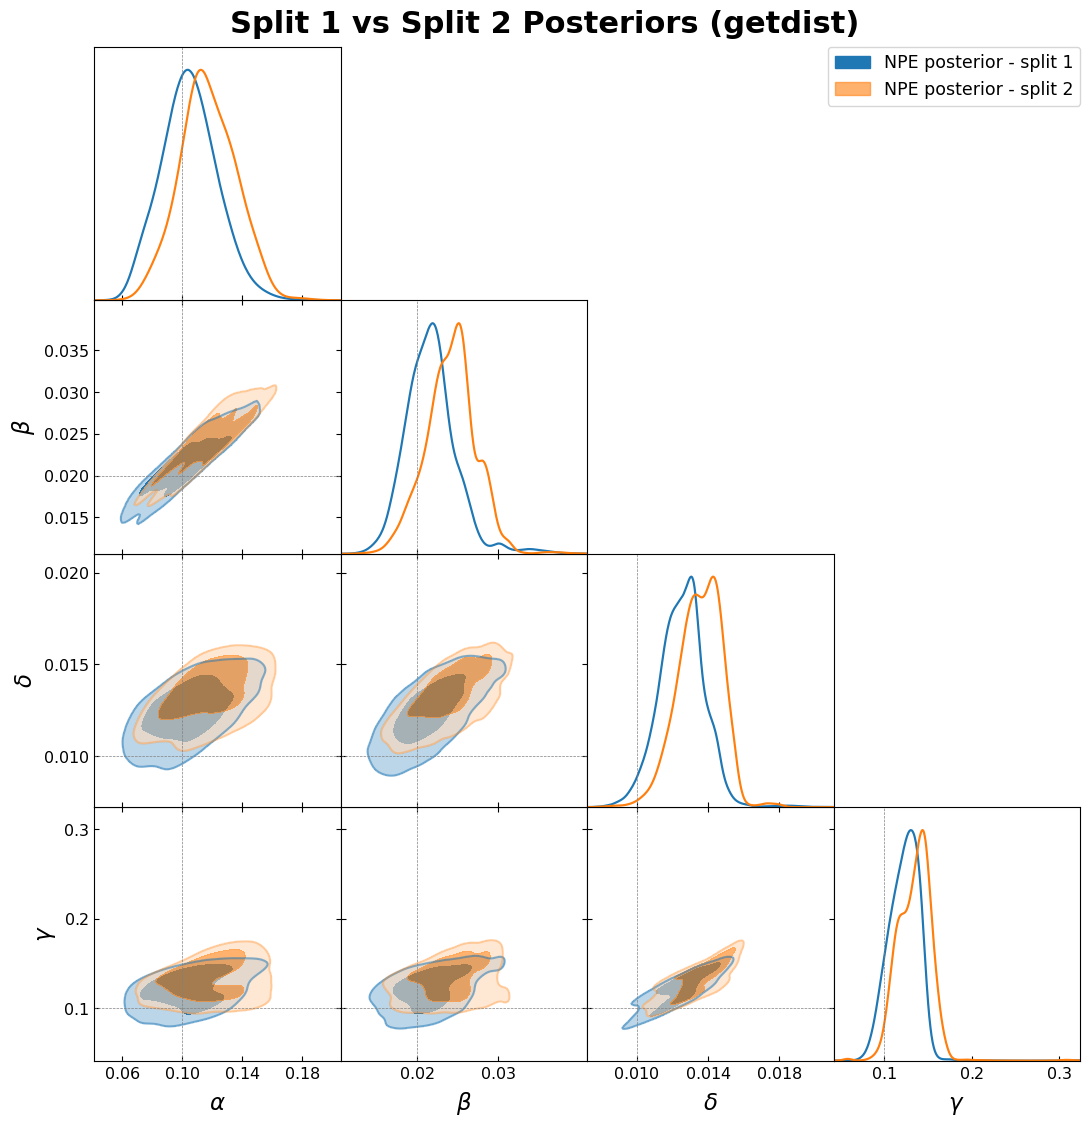

In [9]:
# ============================================================
# getdist versions (Will's Apr-14 ask)
# Peak=1 1D marginals so PDF shapes can be compared without sample bias.
# ============================================================

#%pip install --quiet getdist

from getdist import MCSamples, plots as gd_plots

LV_GD_NAMES  = ["alpha", "beta", "delta", "gamma"]
LV_GD_LABELS = [r"\alpha", r"\beta", r"\delta", r"\gamma"]


def _to_mcsamples_lv(samples, label):
    arr = samples.numpy() if torch.is_tensor(samples) else np.asarray(samples)
    arr = arr.astype(float).copy()
    return MCSamples(samples=arr, names=LV_GD_NAMES, labels=LV_GD_LABELS, label=label)


def _make_plotter_lv(width_inch=11):
    g = gd_plots.get_subplot_plotter(width_inch=width_inch)
    g.settings.norm_1d_density          = True
    g.settings.alpha_filled_add         = 0.6
    g.settings.axes_fontsize            = 13
    g.settings.lab_fontsize             = 18
    g.settings.legend_fontsize          = 14
    g.settings.linewidth                = 2.0
    g.settings.linewidth_contour        = 2.0
    g.settings.solid_contour_palefactor = 0.7
    return g


def _true_markers_lv(true_parameters):
    t = np.asarray(true_parameters, dtype=float).reshape(-1)
    return dict(zip(LV_GD_NAMES, t))


def plot_prior_vs_posteriors_lv_gd(samples1, samples2, prior, true_parameters,
                                    systematic_label=None, n_prior_samples=50_000):
    sys_label = systematic_label or "NPE posterior - split 2"
    mc_prior = _to_mcsamples_lv(prior.sample((n_prior_samples,)), "Prior")
    mc1      = _to_mcsamples_lv(samples1, "NPE posterior - split 1")
    mc2      = _to_mcsamples_lv(samples2, sys_label)

    g = _make_plotter_lv()
    g.triangle_plot(
        [mc_prior, mc1, mc2],
        filled=True,
        contour_colors=["#888888", "#1f77b4", "#ff7f0e"],
        markers=_true_markers_lv(true_parameters),
        legend_loc="upper right",
    )
    plt.suptitle("Prior vs Posteriors (getdist)", fontsize=22, fontweight="bold", y=1.02)
    plt.show()


def plot_posteriors_overlaid_lv_gd(samples1, samples2, true_parameters,
                                     systematic_label=None):
    sys_label = systematic_label or "NPE posterior - split 2"
    mc1 = _to_mcsamples_lv(samples1, "NPE posterior - split 1")
    mc2 = _to_mcsamples_lv(samples2, sys_label)

    g = _make_plotter_lv()
    g.triangle_plot(
        [mc1, mc2],
        filled=True,
        contour_colors=["#1f77b4", "#ff7f0e"],
        markers=_true_markers_lv(true_parameters),
        legend_loc="upper right",
    )
    plt.suptitle("Split 1 vs Split 2 Posteriors (getdist)",
                 fontsize=22, fontweight="bold", y=1.02)
    plt.show()


# --- Run ---
plot_prior_vs_posteriors_lv_gd(
    samples1, samples2, prior1, true_parameters,
    systematic_label="NPE posterior - split 2",
)
plot_posteriors_overlaid_lv_gd(
    samples1, samples2, true_parameters,
    systematic_label="NPE posterior - split 2",
)


In [10]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error

def calibrate_null_dkl(posterior1, posterior2, prior, N, n_theta, distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        
        #print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        #traj_i = simulate_total(theta_i)
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i,split_type)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(


0/100
20/100
40/100
60/100
80/100


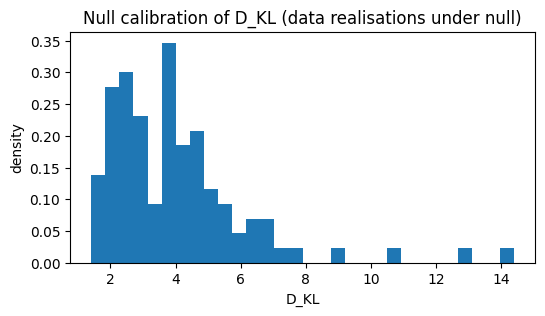

Null 95 percent critical value: 7.333913016319275
DKL observed: 2.229990243911743


In [11]:

dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct,
                                       x_obs1, x_obs2, n_theta=500)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, posterior2_direct, prior1,
                                       100, 500, noise1, n_obs1, sigma_hare1, sigma_lynx1,
                                       obs1, split_type, t_span)
print("DKL observed:", dkl_obs)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def calibrate_null_dkl_neat(posterior1, posterior2, prior, N, n_theta, distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span, dkl_obs):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 200 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i, split_type)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) # obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    # ==========================================
    # PRESENTATION PLOTTING (Consistent Style)
    # ==========================================
    # Larger figure size and high DPI for crisp projection
    plt.figure(figsize=(8, 4.5), dpi=150)
    
    # Add a clean grid behind the histogram bars
    plt.gca().set_axisbelow(True)
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.grid(axis='x', linestyle=':', alpha=0.4)  

    # Original style: solid bars, no gaps
    plt.hist(dkls, bins=30, density=True, color='tab:blue', label='Null Distribution ($H_0$)')
    
    # Vertical lines for Observed D_KL and Critical Value
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')
    
    # Labels and Titles: Fixed capitalization and added padding
    plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
    plt.ylabel("Probability Density", fontsize=14, labelpad=10)
    plt.title(r"Null Calibration of $D_{KL}$ (Lotka-Volterra)", fontsize=16, pad=15)
    
    # Tick marks: larger fonts
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Upgraded Legend: Solid white background with a crisp border and slight shadow
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)
    
    # Automatically adjust layout so nothing gets cut off
    plt.tight_layout()
    plt.show()

    print(f"Null 95 percent critical value: {crit_val_95:.2f}")

    return dkls, crit_val_95

In [ ]:
dkls_neat, crit_val_95_neat = calibrate_null_dkl_neat(
    posterior1_direct, posterior2_direct, prior1,
    2500, 500,
    noise1, n_obs1, sigma_hare1, sigma_lynx1,
    obs1, split_type, t_span, dkl_obs,
)


: 

: 

: 

: 

: 

In [ ]:

dkl_obs_2, std_obs_2, error_obs_2 = calc_dkl(posterior1_direct, posterior2_direct,
                                              x_obs1, x_obs2, n_theta=2500)


dkls_2, crit_val_95_2 = calibrate_null_dkl(posterior1_direct, posterior2_direct, prior1,
                                           200, 2500, noise1, n_obs1, sigma_hare1, sigma_lynx1,
                                           obs1, split_type, t_span)
print("DKL observed:", dkl_obs_2)


: 

: 

: 

: 

: 

In [ ]:
#loop through N vals to see error as fn of n
N_theta_vals = [100,500,1000,5000,10000]

# empty array to store values
mean_vals=[0]*len(N_theta_vals)
std_dev_vals = [0]*len(N_theta_vals)
error_vals = [0]*len(N_theta_vals)

# generate some random test data, following same process:
def generate_loop_data(prior,distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span):
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        #traj_i = simulate_total(theta_i)
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i,split_type)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data
        return x1_i, x2_i

x1_loop, x2_loop = generate_loop_data(prior1, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)

for i in range(len(N_theta_vals)):
        n_theta = N_theta_vals[i]
        mean_vals[i], std_dev_vals[i], error_vals[i] = calc_dkl(posterior1_direct, posterior1_direct, x1_loop, x2_loop, n_theta = n_theta)
        print(i)



0
1
2
3
4


: 

: 

: 

: 

: 

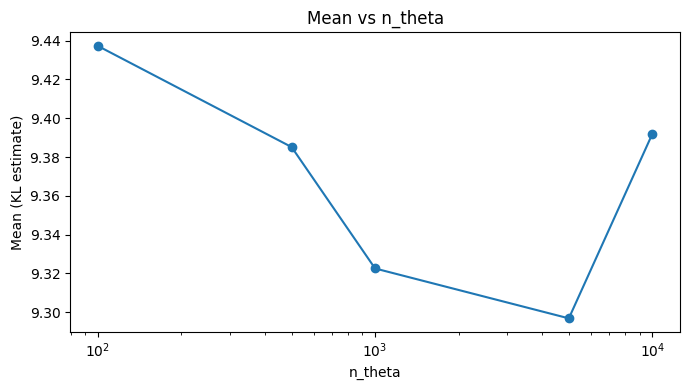

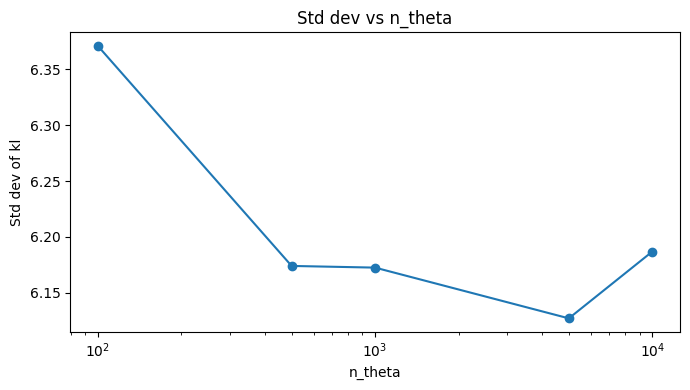

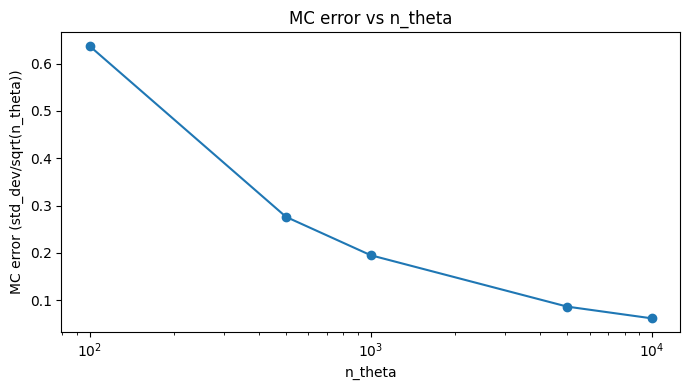

: 

: 

: 

: 

: 

In [ ]:

N_theta_vals = np.array(N_theta_vals, dtype=float)
mean_vals = np.array(mean_vals, dtype=float)
std_dev_vals = np.array(std_dev_vals, dtype=float)
error_vals = np.array(error_vals, dtype=float)

# Plot mean
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, mean_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Mean (KL estimate)")
plt.title("Mean vs n_theta")
plt.tight_layout()
plt.show()

# 2) Std dev vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, std_dev_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Std dev of kl")
plt.title("Std dev vs n_theta")
plt.tight_layout()
plt.show()

# 3) Error vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, error_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("MC error (std_dev/sqrt(n_theta))")
plt.title("MC error vs n_theta")
plt.tight_layout()
plt.show()









In [13]:
# ============================================================
# === CHANGE (2026-05-06): refactored systematic calibration loop ===
# Per LV_Pipeline_Instructions.md (30 Apr supervision) and the 22 Apr
# methodology meeting, the systematic must enter ONLY in the observed
# data — never in training.  The trained NPEs (posterior1, posterior2)
# are both null-trained; the only thing that changes between the
# null-loop and the perturbed-loop below is what we feed in as x1_i.
#
# Two systematic flavours are supported:
#
#   (a) "multiplier" — a percentage increase on a chosen population
#       column of the observed split.  Mirrors a gain miscalibration in
#       the CMB beam test.  Set perturb_col=0 for hare (prey),
#       perturb_col=1 for lynx (predator).
#
#   (b) "noise_swap" — the observed split is generated with a different
#       noise model than the training noise (e.g. train on Gaussian,
#       observe with Poisson).  Models the "two different detectors"
#       situation discussed at the 30 Apr meeting.
#
# The unperturbed/null x2_i is always generated with the training noise.
# ============================================================

def _generate_perturbed_obs(theta_i, n_obs, sigma_hare, sigma_lynx,
                             observation, t_span_full,
                             noise_train, perturb_kind,
                             perturb_col=1, multiplier=1.05,
                             noise_swap_to='poisson'):
    """Return the trajectory used for the perturbed/systematic split.

    Parameters
    ----------
    perturb_kind : {'multiplier', 'noise_swap'}
    perturb_col  : 0 (hare/prey) or 1 (lynx/predator)
    multiplier   : float — only used if perturb_kind == 'multiplier'
    noise_swap_to: str   — only used if perturb_kind == 'noise_swap'
    """
    if perturb_kind == 'multiplier':
        # Generate the same noise model as training, then scale the
        # chosen column. The systematic looks like a gain error.
        traj = simulator_distribution(noise_train, theta_i, n_obs,
                                       sigma_hare, sigma_lynx,
                                       observation, t_span_full)
        traj = traj.copy().astype(float)
        traj[:, perturb_col] *= multiplier
        return traj

    elif perturb_kind == 'noise_swap':
        # Sample with a different noise distribution (e.g. Poisson) —
        # but the training data was Gaussian. Different detector.
        return simulator_distribution(noise_swap_to, theta_i, n_obs,
                                       sigma_hare, sigma_lynx,
                                       observation, t_span_full)
    else:
        raise ValueError(f"Unknown perturb_kind: {perturb_kind}")


def calibrate_null_dkl_and_perturbed(posterior1, posterior2, prior, N, n_theta,
                                       noise_train, n_obs, sigma_hare, sigma_lynx,
                                       observation, split_type, t_span,
                                       perturb_kind='multiplier',
                                       perturb_col=1,
                                       multiplier=1.05,
                                       noise_swap_to='poisson'):
    """Joint null/perturbed calibration. KEEP ONLY for single-multiplier
    one-shot diagnostics; for sweeps use the split helpers below
    (calibrate_null_dkl_only + calibrate_perturb_dkl_only) which avoid
    recomputing the null distribution at every multiplier."""

    dkls           = np.zeros(N)
    dkls_perturbed = np.zeros(N)

    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()

        # --- null trajectory: training noise on the full t_span_full ---
        traj_i = simulator_distribution(noise_train, theta_i, n_obs,
                                         sigma_hare, sigma_lynx,
                                         observation, 2 * t_span)
        obs1_i, obs2_i = choose_splitter(traj_i, split_type)
        x1_i = summarize_simulation(obs1_i)
        x2_i = summarize_simulation(obs2_i)
        dkls[i], _, _ = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta)

        # --- perturbed: same theta, regenerate with systematic on split-1 ---
        traj_i_pert = _generate_perturbed_obs(theta_i, n_obs, sigma_hare, sigma_lynx,
                                                observation, 2 * t_span,
                                                noise_train, perturb_kind,
                                                perturb_col, multiplier,
                                                noise_swap_to)
        obs1_i_pert, _ = choose_splitter(traj_i_pert, split_type)
        x1_i_perturbed = summarize_simulation(obs1_i_pert)
        dkls_perturbed[i], _, _ = calc_dkl(posterior1, posterior2,
                                            x1_i_perturbed, x2_i,
                                            n_theta=n_theta)

    crit_val_95           = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))

    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL"); plt.ylabel("density")
    plt.title("Null calibration of D_KL")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.xlabel("D_KL"); plt.ylabel("density")
    plt.title(f"Perturbed D_KL (kind={perturb_kind})")
    plt.show()

    print("Null 95 percent critical value:    ", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)
    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed


In [ ]:
# === CHANGE (2026-05-06): updated call uses new keyword args ===
# Default systematic: 5% gain miscalibration on the lynx column. To run
# the discrete-noise systematic (Option B from LV_Pipeline_Instructions.md),
# pass perturb_kind='noise_swap', noise_swap_to='poisson'.
dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed = calibrate_null_dkl_and_perturbed(
    posterior1_direct, posterior2_direct, prior1,
    N=100, n_theta=500,
    noise_train=noise_train,
    n_obs=n_obs1, sigma_hare=sigma_hare1, sigma_lynx=sigma_lynx1,
    observation=obs1, split_type=split_type, t_span=t_span,
    perturb_kind='multiplier',  # or 'noise_swap'
    perturb_col=1,              # 1 = lynx (predator); 0 = hare (prey)
    multiplier=1.05,
)


: 

: 

: 

: 

: 

#### Sweep refactor (2026-05-06): null once, perturbed many

Per the SBI sweep pattern (applied to all CMB notebooks on 2026-05-03):
the null distribution is α-independent, so we compute it ONCE at high
N (1000-2000) for a tight 95th-percentile threshold, and then sweep the
perturbed distribution at lower N (200-300) for each multiplier α.


In [14]:
# ============================================================
# === CHANGE (2026-05-06): split helpers for efficient α-sweeps ===
# calibrate_null_dkl_only       — α-independent null distribution
# calibrate_perturb_dkl_only    — perturbed distribution at one α
# (Mirrors the helpers added to the CMB notebooks on 2026-05-03.)
# ============================================================

def calibrate_null_dkl_only(posterior1, posterior2, prior, N, n_theta,
                              noise_train, n_obs, sigma_hare, sigma_lynx,
                              observation, split_type, t_span):
    """Null distribution of D_KL — run ONCE at high N (1000-2000)."""
    dkls = np.zeros(N)
    for i in range(N):
        if i % 200 == 0:
            print(f"[null] {i}/{N}")
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        traj_i = simulator_distribution(noise_train, theta_i, n_obs,
                                         sigma_hare, sigma_lynx,
                                         observation, 2 * t_span)
        obs1_i, obs2_i = choose_splitter(traj_i, split_type)
        x1_i = summarize_simulation(obs1_i)
        x2_i = summarize_simulation(obs2_i)
        dkls[i], _, _ = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta)
    return dkls, float(np.quantile(dkls, 0.95))


def calibrate_perturb_dkl_only(posterior1, posterior2, prior, N, n_theta,
                                 noise_train, n_obs, sigma_hare, sigma_lynx,
                                 observation, split_type, t_span,
                                 perturb_kind='multiplier',
                                 perturb_col=1,
                                 multiplier=1.05,
                                 noise_swap_to='poisson'):
    """Perturbed D_KL distribution at one systematic setting — N=200-300 fine.

    The perturbation is applied to split-1 of the test observation; split-2
    is generated with the training noise (null)."""
    dkls_p = np.zeros(N)
    for i in range(N):
        if i % 100 == 0:
            print(f"[pert] {i}/{N}")
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()

        # null split-2 (training noise)
        traj_i_null = simulator_distribution(noise_train, theta_i, n_obs,
                                              sigma_hare, sigma_lynx,
                                              observation, 2 * t_span)
        _, obs2_i = choose_splitter(traj_i_null, split_type)
        x2_i = summarize_simulation(obs2_i)

        # perturbed split-1
        traj_i_pert = _generate_perturbed_obs(theta_i, n_obs, sigma_hare, sigma_lynx,
                                                observation, 2 * t_span,
                                                noise_train, perturb_kind,
                                                perturb_col, multiplier,
                                                noise_swap_to)
        obs1_i_pert, _ = choose_splitter(traj_i_pert, split_type)
        x1_i_perturbed = summarize_simulation(obs1_i_pert)

        dkls_p[i], _, _ = calc_dkl(posterior1, posterior2,
                                    x1_i_perturbed, x2_i, n_theta=n_theta)

    return dkls_p, float(np.median(dkls_p))


#### Multiplier sweep (Option A from LV_Pipeline_Instructions.md)

Find the smallest multiplier at which the median perturbed D_KL exceeds
the 95% null threshold — i.e. the LV pipeline's sensitivity floor for a
gain-style systematic.


In [15]:
# ============================================================
# === CHANGE (2026-05-06): multiplier sweep for the percentage-increase
# (gain) systematic. Null is computed ONCE at high N; then we loop over
# multipliers at lower N.
# ============================================================

N_null      = 1000
N_pert      = 300
n_theta_sw  = 500

print("--- Computing null distribution (run once) ---")
dkls_null_sw, crit_val_95_sw = calibrate_null_dkl_only(
    posterior1_direct, posterior2_direct, prior1,
    N_null, n_theta_sw,
    noise_train, n_obs1, sigma_hare1, sigma_lynx1,
    obs1, split_type, t_span,
)
print(f"Null 95% critical value: {crit_val_95_sw:.3f}")

multipliers_to_test = [1.005, 1.01, 1.02, 1.03, 1.05, 1.075, 1.10]
sweep_results = {}

for m in multipliers_to_test:
    print(f"\n--- multiplier = {m} ---")
    dkls_p, median_p = calibrate_perturb_dkl_only(
        posterior1_direct, posterior2_direct, prior1,
        N_pert, n_theta_sw,
        noise_train, n_obs1, sigma_hare1, sigma_lynx1,
        obs1, split_type, t_span,
        perturb_kind='multiplier',
        perturb_col=1,
        multiplier=m,
    )
    detected = median_p >= crit_val_95_sw
    sweep_results[m] = (dkls_p, median_p, detected)
    print(f"  median perturbed D_KL = {median_p:.3f}  |  detected = {detected}")

print("\n--- Sweep summary ---")
for m, (_, med, det) in sweep_results.items():
    flag = "DETECTED" if det else "  not   "
    print(f"  multiplier={m:.4f}   median D_KL={med:.3f}   {flag}")


--- Computing null distribution (run once) ---
[null] 0/1000
[null] 200/1000
[null] 400/1000
[null] 600/1000
[null] 800/1000
Null 95% critical value: 8.559

--- multiplier = 1.005 ---
[pert] 0/300
[pert] 100/300
[pert] 200/300
  median perturbed D_KL = 3.468  |  detected = False

--- multiplier = 1.01 ---
[pert] 0/300
[pert] 100/300
[pert] 200/300
  median perturbed D_KL = 3.479  |  detected = False

--- multiplier = 1.02 ---
[pert] 0/300
[pert] 100/300
[pert] 200/300
  median perturbed D_KL = 3.791  |  detected = False

--- multiplier = 1.03 ---
[pert] 0/300
[pert] 100/300
[pert] 200/300
  median perturbed D_KL = 5.075  |  detected = False

--- multiplier = 1.05 ---
[pert] 0/300
[pert] 100/300
[pert] 200/300
  median perturbed D_KL = 6.556  |  detected = False

--- multiplier = 1.075 ---
[pert] 0/300
[pert] 100/300
[pert] 200/300
  median perturbed D_KL = 9.324  |  detected = True

--- multiplier = 1.1 ---
[pert] 0/300
[pert] 100/300
[pert] 200/300
  median perturbed D_KL = 12.958  | 

#### Discrete-noise systematic (Option B from LV_Pipeline_Instructions.md)

Train both splits with Gaussian noise (already done — `noise_train`).
At test time, swap split-1 to a different noise model (Poisson) — the
"two different detectors" scenario. Compares against the same null
distribution computed above.


In [ ]:
# ============================================================
# === CHANGE (2026-05-06): noise-swap systematic test ===
# Only meaningful if noise_train != 'poisson'. If you trained with
# Gaussian (recommended), this swaps split-1 obs to Poisson at test time.
# ============================================================

if noise_train == 'poisson':
    print("Skipping noise-swap test: training noise is already Poisson.")
else:
    print(f"--- Noise swap: train='{noise_train}' -> obs split-1='poisson' ---")
    dkls_swap, median_swap = calibrate_perturb_dkl_only(
        posterior1_direct, posterior2_direct, prior1,
        N_pert, n_theta_sw,
        noise_train, n_obs1, sigma_hare1, sigma_lynx1,
        obs1, split_type, t_span,
        perturb_kind='noise_swap',
        noise_swap_to='poisson',
    )
    detected_swap = median_swap >= crit_val_95_sw
    print(f"  median D_KL (noise-swap) = {median_swap:.3f}  |  null 95% = {crit_val_95_sw:.3f}")
    print(f"  detected = {detected_swap}")

    plt.figure(figsize=(7, 4), dpi=150)
    plt.hist(dkls_null_sw, bins=30, density=True, alpha=0.6,
             color='tab:blue', label=r'Null ($H_0$, train-noise on both)')
    plt.hist(dkls_swap, bins=30, density=True, alpha=0.6,
             color='tab:orange', label=r'Noise-swap (split-1 obs $\to$ Poisson)')
    plt.axvline(crit_val_95_sw, color='red', linestyle='--', linewidth=2,
                label=f'95% critical value ({crit_val_95_sw:.2f})')
    plt.xlabel(r"$D_{KL}$"); plt.ylabel("density")
    plt.title("Discrete-noise systematic test — Lotka-Volterra")
    plt.legend(); plt.tight_layout(); plt.show()


: 

: 

: 

: 

: 

: 

: 

: 

: 

: 